Case Use: Predicting the Impact of Environmental Variables on Fish Migration Patterns
Problem Description:
Marine ecologists aim to understand how various environmental variables influence fish migration patterns. Specifically, they want to model the dependency of fish migration distances on factors such as water temperature, salinity, and ocean currents.

Statistical Technique:
Multiple Regression will be used to build a predictive model that relates multiple independent variables (environmental factors) to a dependent variable (fish migration distance).

Hypothesis:
The hypothesis is that water temperature, salinity, and ocean current speed are significant predictors of the distance that fish migrate seasonally.

Dataset Description:
The dataset includes observations from 200 tagged fish, with the following variables:

Water Temperature (degrees Celsius)
Salinity (PSU)
Ocean Current Speed (km/h)
Migration Distance (km)
Student Task:
The student is tasked with using the provided multiple regression code to build a predictive model for fish migration distances. They are required to:

Interpret the significance of each predictor in the model.
Adjust the model to include interaction terms if hypothesized that interactions between variables may be significant.
Validate the assumptions of multiple regression, including checking for multicollinearity and heteroscedasticity.

                            OLS Regression Results                            
Dep. Variable:     Migration Distance   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     208.5
Date:                Sun, 19 May 2024   Prob (F-statistic):           1.01e-60
Time:                        23:51:33   Log-Likelihood:                -744.75
No. Observations:                 200   AIC:                             1498.
Df Residuals:                     196   BIC:                             1511.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.5064      8.225     -0.548

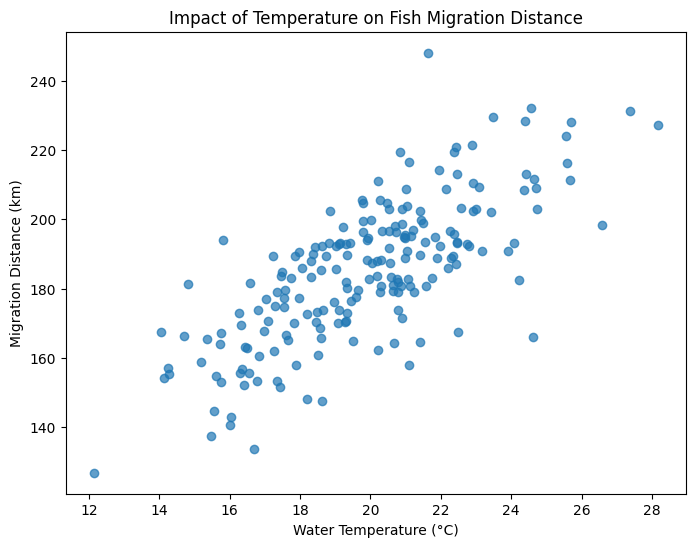

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
data_size = 200
temperature = np.random.normal(20, 3, data_size)  # Water temperature
salinity = np.random.normal(35, 5, data_size)     # Salinity
current_speed = np.random.normal(5, 1, data_size) # Ocean current speed
migration_distance = (5 * temperature + 2 * salinity + 3 * current_speed + np.random.normal(0, 10, data_size))

# Create a DataFrame
data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity': salinity,
    'Current Speed': current_speed,
    'Migration Distance': migration_distance
})

# Multiple Regression Model
X = data[['Temperature', 'Salinity', 'Current Speed']]
X = sm.add_constant(X)  # Adding a constant term for the intercept
y = data['Migration Distance']

model = sm.OLS(y, X).fit()

# Display the regression results
print(model.summary())

# Plotting temperature vs. migration to visualize potential relationships
plt.figure(figsize=(8, 6))
plt.scatter(data['Temperature'], y, alpha=0.7)
plt.title('Impact of Temperature on Fish Migration Distance')
plt.xlabel('Water Temperature (°C)')
plt.ylabel('Migration Distance (km)')
plt.show()


*Instructions for Students*:
Run the provided code to understand the initial regression results.
Experiment with adding quadratic terms for temperature and current speed to test for non-linear effects.
Check the residuals of the model to assess whether they meet the assumptions of normality and constant variance.
Interpret the coefficients and their p-values to assess which environmental factors are significant predictors of migration distance.
This case use allows students to practically apply multiple regression to a realistic scenario in marine ecology, fostering deeper understanding of statistical modeling and environmental science.



**Experimenting with Quadratic Terms**

To test for non-linear effects, you can add quadratic terms for temperature and current speed. This can be done by creating new columns in the DataFrame for the squared values of temperature and current speed, and hen including these new columns in the regression model. **bold text**

In [ ]:
data['Temperature_Squared'] = data['Temperature'] ** 2
data['Current Speed_Squared'] = data['Current Speed'] ** 2

X_quadratic = data[['Temperature', 'Salinity', 'Current Speed', 'Temperature_Squared', 'Current Speed_Squared']]
X_quadratic = sm.add_constant(X_quadratic)

model_quadratic = sm.OLS(y, X_quadratic).fit()
print(model_quadratic.summary())

                            OLS Regression Results                            
Dep. Variable:     Migration Distance   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     124.0
Date:                Sun, 19 May 2024   Prob (F-statistic):           1.86e-58
Time:                        23:51:37   Log-Likelihood:                -744.62
No. Observations:                 200   AIC:                             1501.
Df Residuals:                     194   BIC:                             1521.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -17.40

Checking the Residuals
To assess whether the residuals meet the assumptions of normality and constant variance, you can plot the residuals against the fitted values.

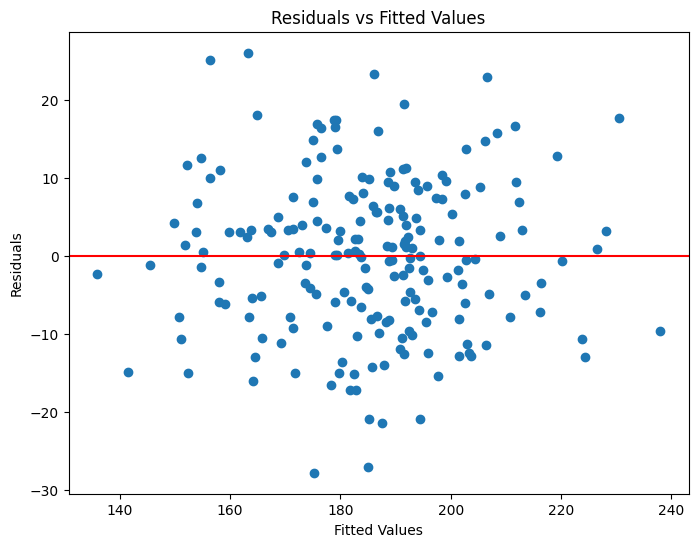

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(model.fittedvalues, model.resid)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

If the residuals are randomly dispersed around the horizontal axis, the assumptions of normality and constant variance are met.

Interpreting the Coefficients and Their P-values
After fitting the model with or without quadratic terms, interpret the coefficients and their p-values to assess which environmental factors are significant predictors of migration distance.

For example, if the p-value for temperature is less than 0.05, you can conclude that temperature has a significant effect on fish migration distance. The coefficient for temperature represents the change in migration distance associated with a one-degree increase in temperature, holding all other variables constant.

By following these instructions, you will gain hands-on experience applying multiple regression to a real-world scenario in marine ecology, deepening your understanding of statistical modeling and environmental science.